inputs shape: torch.Size([8, 3, 16, 16])
targets shape: torch.Size([8, 1, 16, 16])


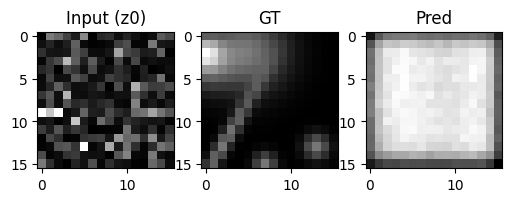

Epoch 1/100, Loss: 0.062014
Epoch 2/100, Loss: 0.061039
Epoch 3/100, Loss: 0.059634
Epoch 4/100, Loss: 0.059144
Epoch 5/100, Loss: 0.057549


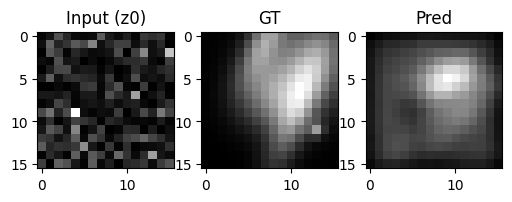

Epoch 6/100, Loss: 0.057901
Epoch 7/100, Loss: 0.056258
Epoch 8/100, Loss: 0.055566
Epoch 9/100, Loss: 0.049803
Epoch 10/100, Loss: 0.044140


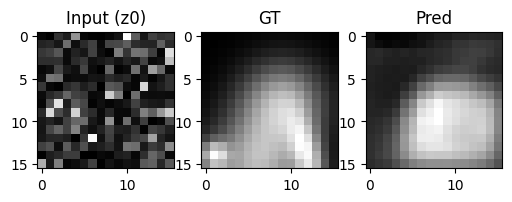

Epoch 11/100, Loss: 0.037777
Epoch 12/100, Loss: 0.032631
Epoch 13/100, Loss: 0.030114
Epoch 14/100, Loss: 0.027372
Epoch 15/100, Loss: 0.025791


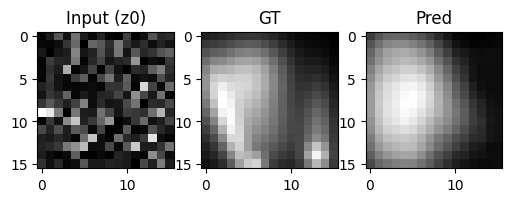

Epoch 16/100, Loss: 0.023246
Epoch 17/100, Loss: 0.021886
Epoch 18/100, Loss: 0.019819
Epoch 19/100, Loss: 0.019152
Epoch 20/100, Loss: 0.018123


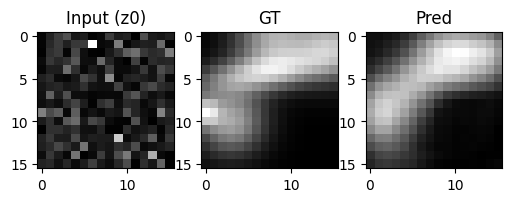

Epoch 21/100, Loss: 0.017884
Epoch 22/100, Loss: 0.016560
Epoch 23/100, Loss: 0.016946
Epoch 24/100, Loss: 0.015199
Epoch 25/100, Loss: 0.014595


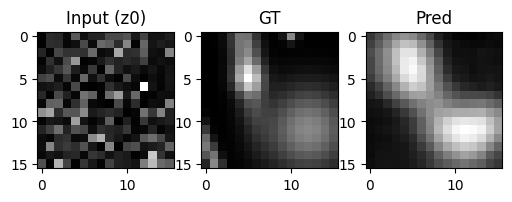

Epoch 26/100, Loss: 0.013906
Epoch 27/100, Loss: 0.013312
Epoch 28/100, Loss: 0.013113
Epoch 29/100, Loss: 0.012714
Epoch 30/100, Loss: 0.012525


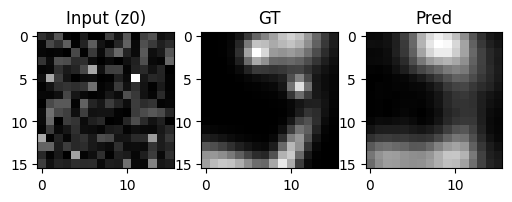

Epoch 31/100, Loss: 0.012052
Epoch 32/100, Loss: 0.011467
Epoch 33/100, Loss: 0.011153
Epoch 34/100, Loss: 0.010979
Epoch 35/100, Loss: 0.010634


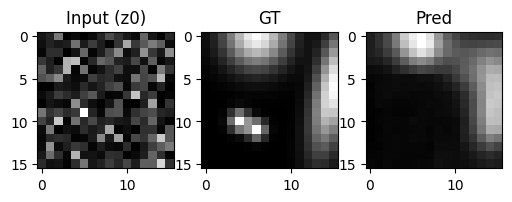

Epoch 36/100, Loss: 0.010567
Epoch 37/100, Loss: 0.010102
Epoch 38/100, Loss: 0.009719
Epoch 39/100, Loss: 0.009433
Epoch 40/100, Loss: 0.009170


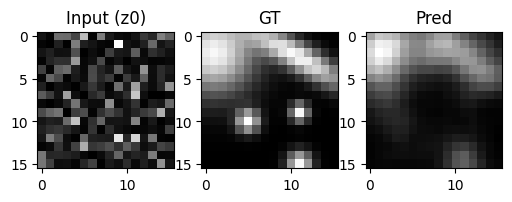

Epoch 41/100, Loss: 0.008945
Epoch 42/100, Loss: 0.008695
Epoch 43/100, Loss: 0.008497
Epoch 44/100, Loss: 0.008343
Epoch 45/100, Loss: 0.008295


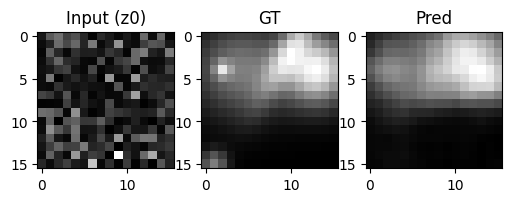

Epoch 46/100, Loss: 0.008321
Epoch 47/100, Loss: 0.007756
Epoch 48/100, Loss: 0.007708
Epoch 49/100, Loss: 0.007559
Epoch 50/100, Loss: 0.007268


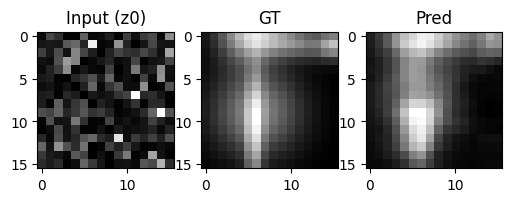

Epoch 51/100, Loss: 0.007093
Epoch 52/100, Loss: 0.007199
Epoch 53/100, Loss: 0.007713
Epoch 54/100, Loss: 0.007538
Epoch 55/100, Loss: 0.007904


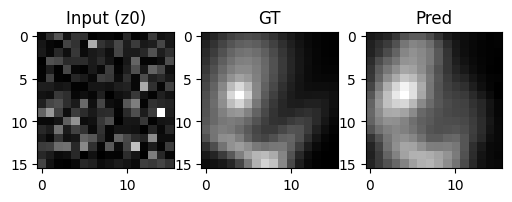

Epoch 56/100, Loss: 0.007438
Epoch 57/100, Loss: 0.006668
Epoch 58/100, Loss: 0.006164
Epoch 59/100, Loss: 0.006022
Epoch 60/100, Loss: 0.005668


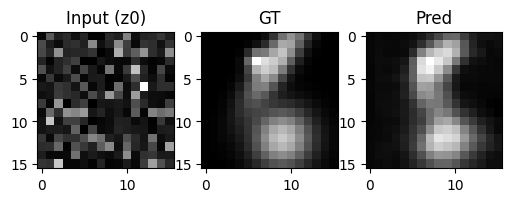

Epoch 61/100, Loss: 0.005512
Epoch 62/100, Loss: 0.005620
Epoch 63/100, Loss: 0.005569
Epoch 64/100, Loss: 0.005432
Epoch 65/100, Loss: 0.005115


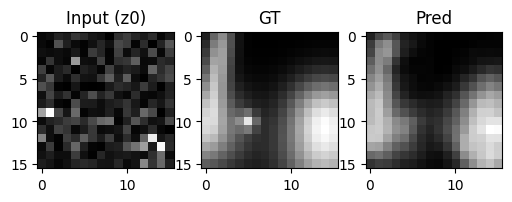

Epoch 66/100, Loss: 0.004931
Epoch 67/100, Loss: 0.004862
Epoch 68/100, Loss: 0.004811
Epoch 69/100, Loss: 0.004766
Epoch 70/100, Loss: 0.004568


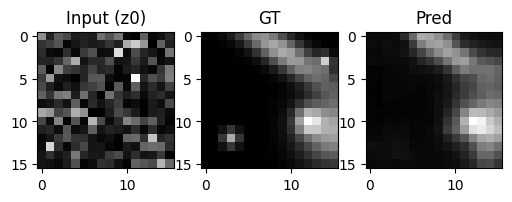

Epoch 71/100, Loss: 0.004326
Epoch 72/100, Loss: 0.004360
Epoch 73/100, Loss: 0.004246
Epoch 74/100, Loss: 0.004074
Epoch 75/100, Loss: 0.003865


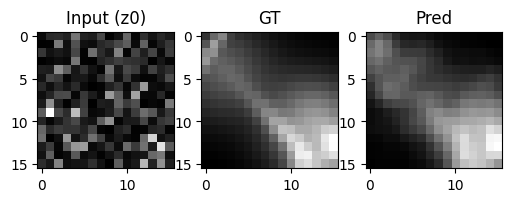

Epoch 76/100, Loss: 0.003774
Epoch 77/100, Loss: 0.003657
Epoch 78/100, Loss: 0.003557
Epoch 79/100, Loss: 0.003512
Epoch 80/100, Loss: 0.003434


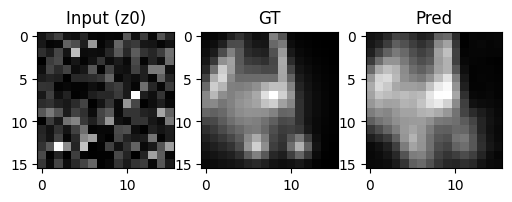

Epoch 81/100, Loss: 0.003595
Epoch 82/100, Loss: 0.003701
Epoch 83/100, Loss: 0.003620
Epoch 84/100, Loss: 0.003416
Epoch 85/100, Loss: 0.003395


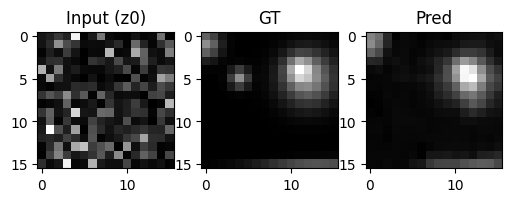

Epoch 86/100, Loss: 0.003290
Epoch 87/100, Loss: 0.003255
Epoch 88/100, Loss: 0.003213
Epoch 89/100, Loss: 0.003042
Epoch 90/100, Loss: 0.003085


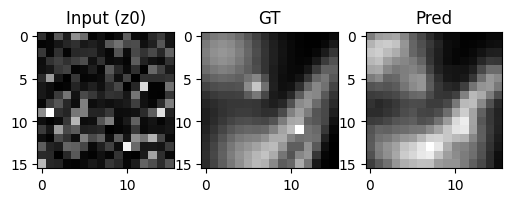

Epoch 91/100, Loss: 0.003193
Epoch 92/100, Loss: 0.003069
Epoch 93/100, Loss: 0.003057
Epoch 94/100, Loss: 0.002996
Epoch 95/100, Loss: 0.002708


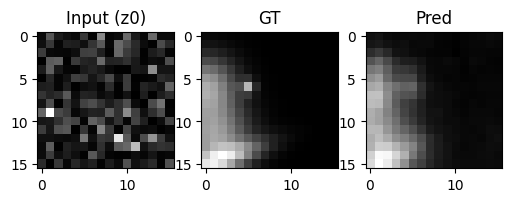

Epoch 96/100, Loss: 0.002621
Epoch 97/100, Loss: 0.002451
Epoch 98/100, Loss: 0.002350
Epoch 99/100, Loss: 0.002291
Epoch 100/100, Loss: 0.002277


In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.fft import fft2, ifft2
import matplotlib.pyplot as plt

# ----------------------------
# PARAMETERS
# ----------------------------
wavelength = 520e-9
pixel_size = 6.5e-6
nx, ny = 32, 32
prop_distance = 0.01
mask_fraction = 0.5
n_train = 500
n_blobs = 5
batch_size = 4
n_epochs = 200


nx, ny = 16, 16      # smaller image
n_train = 200        # less data
batch_size = 8       # more parallelism
n_epochs = 100        # quick test
n_blobs = 3          # simpler objects

z_list = [0.009, 0.011]  # only 2 planes
K = len(z_list)

# ----------------------------
# RANDOM PHASE MASK
# ----------------------------
phase_mask = np.exp(1j * 2*np.pi*np.random.rand(nx, ny))

# ----------------------------
# FRESNEL PROPAGATION
# ----------------------------
def fresnel_propagate(Uin, z, wavelength, pixel_size):
    fx = np.fft.fftfreq(Uin.shape[0], pixel_size)
    fy = np.fft.fftfreq(Uin.shape[1], pixel_size)
    FX, FY = np.meshgrid(fx, fy)
    H = np.exp(-1j * np.pi * wavelength * z * (FX**2 + FY**2))
    Uout = ifft2(fft2(Uin) * H)
    return Uout

# ----------------------------
# GENERATE RANDOM 2D OBJECT
# ----------------------------
def random_2d_object(nx, ny, n_blobs=None):
    obj = np.zeros((nx, ny))

    x = np.arange(nx)[:, None]
    y = np.arange(ny)[None, :]

    # ------------------
    # BLOBS (medium scale)
    # ------------------
    n_blobs = np.random.randint(1, 4)
    for _ in range(n_blobs):
        x0, y0 = np.random.randint(0, nx), np.random.randint(0, ny)
        sigma = np.random.uniform(2, 4)
        obj += np.exp(-((x-x0)**2 + (y-y0)**2)/(2*sigma**2))

    # ------------------
    # POINTS (small scale)
    # ------------------
    n_points = np.random.randint(1, 4)
    for _ in range(n_points):
        x0, y0 = np.random.randint(0, nx), np.random.randint(0, ny)
        sigma = np.random.uniform(0.5, 1.2)
        obj += np.exp(-((x-x0)**2 + (y-y0)**2)/(2*sigma**2))

    # ------------------
    # LINES (elongated Gaussians)
    # ------------------
    n_lines = np.random.randint(1, 3)
    for _ in range(n_lines):
        x0, y0 = np.random.uniform(0, nx), np.random.uniform(0, ny)
        theta = np.random.uniform(0, np.pi)

        # rotate coordinates
        xr = (x - x0)*np.cos(theta) + (y - y0)*np.sin(theta)
        yr = -(x - x0)*np.sin(theta) + (y - y0)*np.cos(theta)

        sigma_long = np.random.uniform(3, 6)
        sigma_short = np.random.uniform(0.5, 1.5)

        obj += np.exp(-(xr**2)/(2*sigma_long**2) - (yr**2)/(2*sigma_short**2))

    # normalize
    obj /= obj.max() + 1e-8

    return obj

# ----------------------------
# SIMULATE IMAGE WITH MASK
# ----------------------------
def simulate_image(obj, phase_mask, prop_distance, mask_fraction):
    z1 = prop_distance * mask_fraction
    z2 = prop_distance * (1 - mask_fraction)
    U = obj.astype(np.complex64)
    U = fresnel_propagate(U, z1, wavelength, pixel_size)
    U = U * phase_mask
    U = fresnel_propagate(U, z2, wavelength, pixel_size)
    img = np.abs(U)**2
    img /= img.max()
    return img

# ----------------------------
# GENERATE TRAINING DATA
# ----------------------------
z_list = [0.008, 0.01, 0.012]  # 3 distances
K = len(z_list)

def simulate_multiz(obj, phase_mask, z_list, mask_fraction):
    imgs = []
    for z in z_list:
        z1 = z * mask_fraction
        z2 = z * (1 - mask_fraction)

        U = obj.astype(np.complex64)
        U = fresnel_propagate(U, z1, wavelength, pixel_size)
        U = U * phase_mask
        U = fresnel_propagate(U, z2, wavelength, pixel_size)

        img = np.abs(U)**2
        img /= img.max()
        imgs.append(img)

    return np.stack(imgs, axis=0)  # shape: (K, nx, ny)


X_train, Y_train = [], []

for _ in range(n_train):
    obj = random_2d_object(nx, ny, n_blobs)
    imgs = simulate_multiz(obj, phase_mask, z_list, mask_fraction)

    X_train.append(imgs)
    Y_train.append(obj)

X_train = np.array(X_train, dtype=np.float32)   # (N, K, nx, ny)
Y_train = np.array(Y_train, dtype=np.float32)   # (N, nx, ny)

# ----------------------------
# PYTORCH DATASET
# ----------------------------
class LLFMDataset2D(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X)
        self.Y = torch.tensor(Y)[:, None]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataloader = DataLoader(LLFMDataset2D(X_train, Y_train), batch_size=batch_size, shuffle=True)

# ----------------------------
# DEFINE 2D CNN MODEL
# ----------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()

        self.down1 = DoubleConv(in_ch, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, out_ch, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))

        b = self.bridge(self.pool2(d2))

        u2 = self.up2(b)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final(u1)

model = UNetSmall(in_ch=K, out_ch=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ----------------------------
# TRAINING LOOP
# ----------------------------
for epoch in range(n_epochs):
    running_loss = 0.0

    for i, (inputs, targets) in enumerate(dataloader):

        if epoch == 0 and i == 0:
            print("inputs shape:", inputs.shape)
            print("targets shape:", targets.shape)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    # ----------------------------
    # PLOT ONLY EVERY 5 EPOCHS
    # ----------------------------
    if epoch % 5 == 0:
        with torch.no_grad():
            test_in, test_gt = next(iter(dataloader))
            pred = model(test_in)

            plt.figure(figsize=(6,2))

            plt.subplot(1,3,1)
            plt.title("Input (z0)")
            plt.imshow(test_in[0,0].cpu(), cmap='gray')

            plt.subplot(1,3,2)
            plt.title("GT")
            plt.imshow(test_gt[0,0].cpu(), cmap='gray')

            plt.subplot(1,3,3)
            plt.title("Pred")
            plt.imshow(pred[0,0].cpu(), cmap='gray')

            plt.show()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {running_loss/len(dataloader.dataset):.6f}")

inputs shape: torch.Size([8, 3, 16, 16])
targets shape: torch.Size([8, 1, 16, 16])


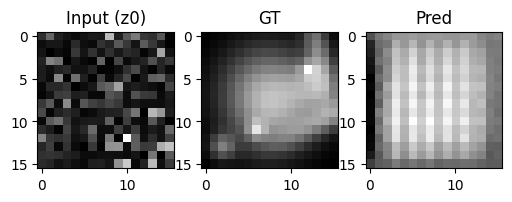

Epoch 1/100, Loss: 0.194275
Epoch 2/100, Loss: 0.190273
Epoch 3/100, Loss: 0.189389
Epoch 4/100, Loss: 0.187425
Epoch 5/100, Loss: 0.183362


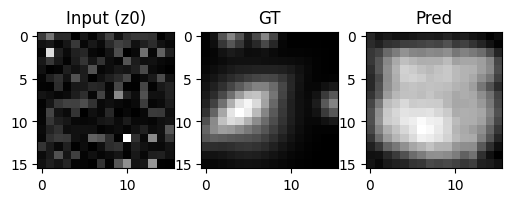

Epoch 6/100, Loss: 0.180657
Epoch 7/100, Loss: 0.171342
Epoch 8/100, Loss: 0.164678
Epoch 9/100, Loss: 0.146121
Epoch 10/100, Loss: 0.145055


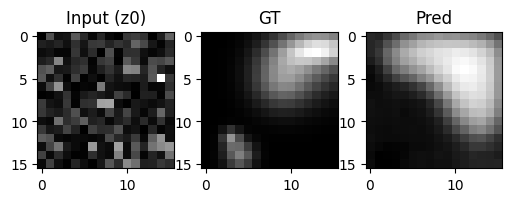

Epoch 11/100, Loss: 0.133716
Epoch 12/100, Loss: 0.125259
Epoch 13/100, Loss: 0.121935
Epoch 14/100, Loss: 0.114907
Epoch 15/100, Loss: 0.113762


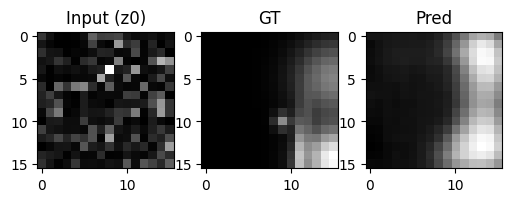

Epoch 16/100, Loss: 0.104807
Epoch 17/100, Loss: 0.100148
Epoch 18/100, Loss: 0.096920
Epoch 19/100, Loss: 0.093028
Epoch 20/100, Loss: 0.094462


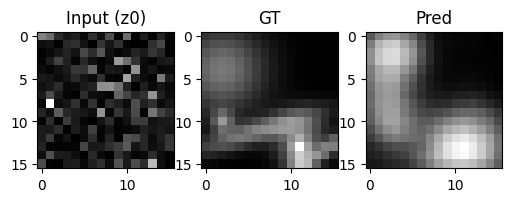

Epoch 21/100, Loss: 0.090269
Epoch 22/100, Loss: 0.086760
Epoch 23/100, Loss: 0.082171
Epoch 24/100, Loss: 0.080186
Epoch 25/100, Loss: 0.078087


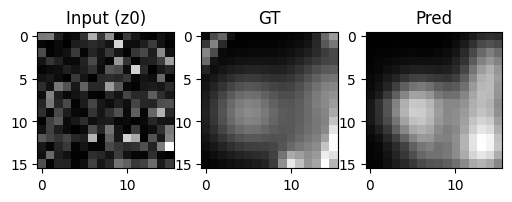

Epoch 26/100, Loss: 0.076502
Epoch 27/100, Loss: 0.073818
Epoch 28/100, Loss: 0.074740
Epoch 29/100, Loss: 0.071731
Epoch 30/100, Loss: 0.071362


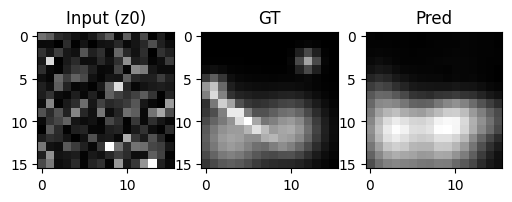

Epoch 31/100, Loss: 0.070007
Epoch 32/100, Loss: 0.073451
Epoch 33/100, Loss: 0.067920
Epoch 34/100, Loss: 0.067325
Epoch 35/100, Loss: 0.066255


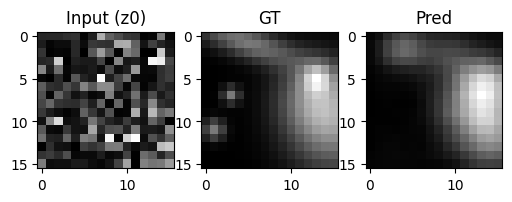

Epoch 36/100, Loss: 0.062477
Epoch 37/100, Loss: 0.061410
Epoch 38/100, Loss: 0.061066
Epoch 39/100, Loss: 0.059265
Epoch 40/100, Loss: 0.062400


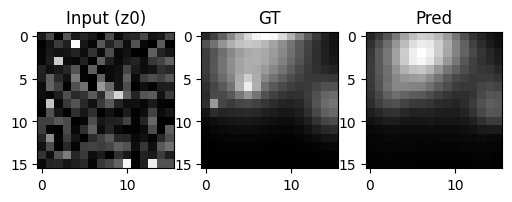

Epoch 41/100, Loss: 0.063456
Epoch 42/100, Loss: 0.060265
Epoch 43/100, Loss: 0.057418
Epoch 44/100, Loss: 0.055083
Epoch 45/100, Loss: 0.056108


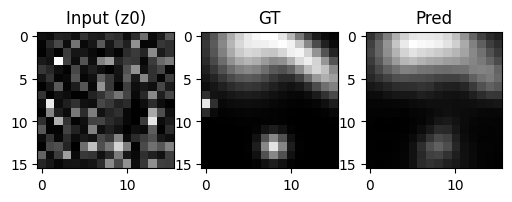

Epoch 46/100, Loss: 0.054845
Epoch 47/100, Loss: 0.055026
Epoch 48/100, Loss: 0.053174
Epoch 49/100, Loss: 0.052688
Epoch 50/100, Loss: 0.051624


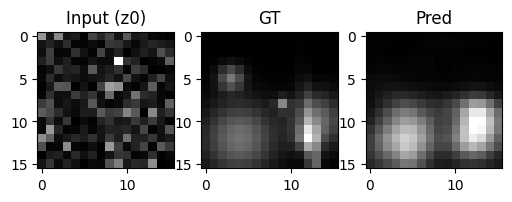

Epoch 51/100, Loss: 0.049166
Epoch 52/100, Loss: 0.048304
Epoch 53/100, Loss: 0.049555
Epoch 54/100, Loss: 0.048379
Epoch 55/100, Loss: 0.047388


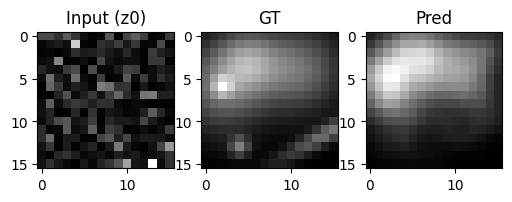

Epoch 56/100, Loss: 0.046576
Epoch 57/100, Loss: 0.045301
Epoch 58/100, Loss: 0.044885
Epoch 59/100, Loss: 0.043978
Epoch 60/100, Loss: 0.044157


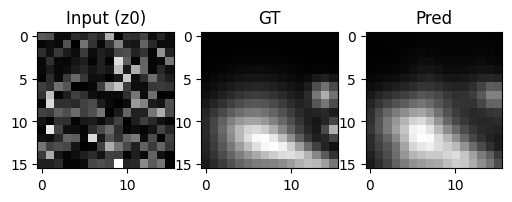

Epoch 61/100, Loss: 0.044687
Epoch 62/100, Loss: 0.043424
Epoch 63/100, Loss: 0.042797
Epoch 64/100, Loss: 0.043773
Epoch 65/100, Loss: 0.041265


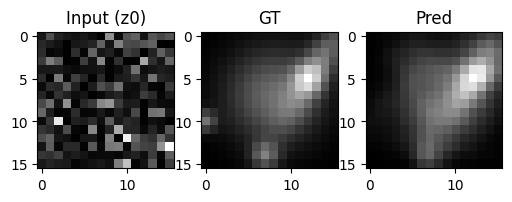

Epoch 66/100, Loss: 0.039799
Epoch 67/100, Loss: 0.038531
Epoch 68/100, Loss: 0.038328
Epoch 69/100, Loss: 0.039896
Epoch 70/100, Loss: 0.038588


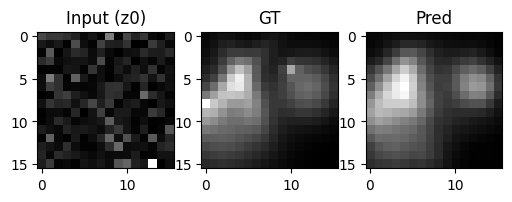

Epoch 71/100, Loss: 0.037049
Epoch 72/100, Loss: 0.036022
Epoch 73/100, Loss: 0.037724
Epoch 74/100, Loss: 0.037915
Epoch 75/100, Loss: 0.035806


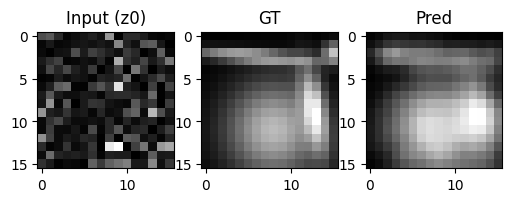

Epoch 76/100, Loss: 0.035480
Epoch 77/100, Loss: 0.034917
Epoch 78/100, Loss: 0.035199
Epoch 79/100, Loss: 0.034421
Epoch 80/100, Loss: 0.034524


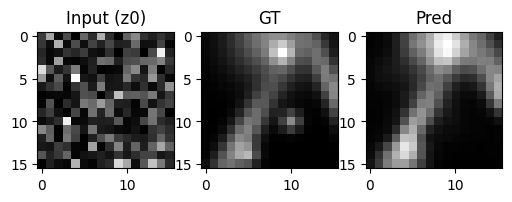

Epoch 81/100, Loss: 0.033508
Epoch 82/100, Loss: 0.032729
Epoch 83/100, Loss: 0.032090
Epoch 84/100, Loss: 0.035021
Epoch 85/100, Loss: 0.032579


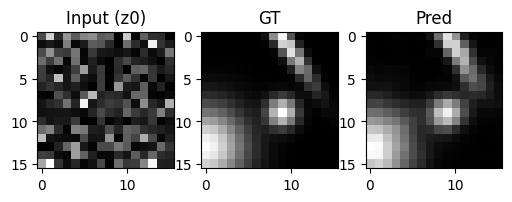

Epoch 86/100, Loss: 0.034376
Epoch 87/100, Loss: 0.033368
Epoch 88/100, Loss: 0.031327
Epoch 89/100, Loss: 0.031253
Epoch 90/100, Loss: 0.030920


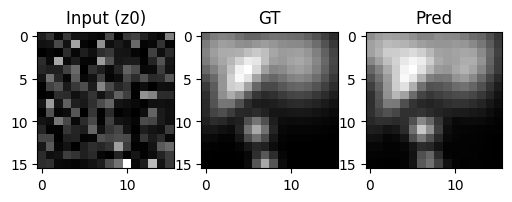

Epoch 91/100, Loss: 0.029596
Epoch 92/100, Loss: 0.028496
Epoch 93/100, Loss: 0.028735
Epoch 94/100, Loss: 0.029080
Epoch 95/100, Loss: 0.028583


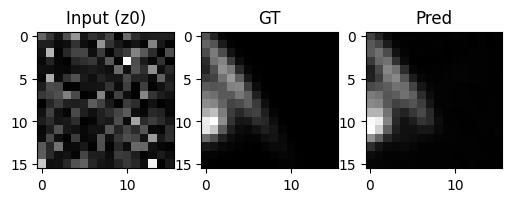

Epoch 96/100, Loss: 0.027094
Epoch 97/100, Loss: 0.026133
Epoch 98/100, Loss: 0.027416
Epoch 99/100, Loss: 0.026398
Epoch 100/100, Loss: 0.028827


In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.fft import fft2, ifft2
import matplotlib.pyplot as plt

# ----------------------------
# PARAMETERS
# ----------------------------
wavelength = 520e-9
pixel_size = 6.5e-6
nx, ny = 32, 32
prop_distance = 0.01
mask_fraction = 0.5
n_train = 500
n_blobs = 5
batch_size = 4
n_epochs = 200


nx, ny = 16, 16      # smaller image
n_train = 200        # less data
batch_size = 8       # more parallelism
n_epochs = 100        # quick test
n_blobs = 3          # simpler objects

z_list = [0.008, 0.009, 0.01, 0.011, 0.012]
K = len(z_list)

# ----------------------------
# RANDOM PHASE MASK
# ----------------------------
phase_mask = np.exp(1j * 2*np.pi*np.random.rand(nx, ny))

# ----------------------------
# FRESNEL PROPAGATION
# ----------------------------
def fresnel_propagate(Uin, z, wavelength, pixel_size):
    fx = np.fft.fftfreq(Uin.shape[0], pixel_size)
    fy = np.fft.fftfreq(Uin.shape[1], pixel_size)
    FX, FY = np.meshgrid(fx, fy)
    H = np.exp(-1j * np.pi * wavelength * z * (FX**2 + FY**2))
    Uout = ifft2(fft2(Uin) * H)
    return Uout

# ----------------------------
# GENERATE RANDOM 2D OBJECT
# ----------------------------
def random_2d_object(nx, ny, n_blobs=None):
    obj = np.zeros((nx, ny))

    x = np.arange(nx)[:, None]
    y = np.arange(ny)[None, :]

    # ------------------
    # BLOBS (medium scale)
    # ------------------
    n_blobs = np.random.randint(1, 4)
    for _ in range(n_blobs):
        x0, y0 = np.random.randint(0, nx), np.random.randint(0, ny)
        sigma = np.random.uniform(2, 4)
        obj += np.exp(-((x-x0)**2 + (y-y0)**2)/(2*sigma**2))

    # ------------------
    # POINTS (small scale)
    # ------------------
    n_points = np.random.randint(1, 4)
    for _ in range(n_points):
        x0, y0 = np.random.randint(0, nx), np.random.randint(0, ny)
        sigma = np.random.uniform(0.5, 1.2)
        obj += np.exp(-((x-x0)**2 + (y-y0)**2)/(2*sigma**2))

    # ------------------
    # LINES (elongated Gaussians)
    # ------------------
    n_lines = np.random.randint(1, 3)
    for _ in range(n_lines):
        x0, y0 = np.random.uniform(0, nx), np.random.uniform(0, ny)
        theta = np.random.uniform(0, np.pi)

        # rotate coordinates
        xr = (x - x0)*np.cos(theta) + (y - y0)*np.sin(theta)
        yr = -(x - x0)*np.sin(theta) + (y - y0)*np.cos(theta)

        sigma_long = np.random.uniform(3, 6)
        sigma_short = np.random.uniform(0.5, 1.5)

        obj += np.exp(-(xr**2)/(2*sigma_long**2) - (yr**2)/(2*sigma_short**2))

    # normalize
    obj /= obj.max() + 1e-8

    return obj

# ----------------------------
# SIMULATE IMAGE WITH MASK
# ----------------------------
def simulate_image(obj, phase_mask, prop_distance, mask_fraction):
    z1 = prop_distance * mask_fraction
    z2 = prop_distance * (1 - mask_fraction)
    U = obj.astype(np.complex64)
    U = fresnel_propagate(U, z1, wavelength, pixel_size)
    U = U * phase_mask
    U = fresnel_propagate(U, z2, wavelength, pixel_size)
    img = np.abs(U)**2
    img /= img.max()
    return img

# ----------------------------
# GENERATE TRAINING DATA
# ----------------------------
z_list = [0.008, 0.01, 0.012]  # 3 distances
K = len(z_list)

def simulate_multiz(obj, phase_mask, z_list, mask_fraction):
    imgs = []
    for z in z_list:
        z1 = z * mask_fraction
        z2 = z * (1 - mask_fraction)

        U = obj.astype(np.complex64)
        U = fresnel_propagate(U, z1, wavelength, pixel_size)
        U = U * phase_mask
        U = fresnel_propagate(U, z2, wavelength, pixel_size)

        img = np.abs(U)**2
        img /= img.max()
        imgs.append(img)

    return np.stack(imgs, axis=0)  # shape: (K, nx, ny)


X_train, Y_train = [], []

for _ in range(n_train):
    obj = random_2d_object(nx, ny, n_blobs)
    imgs = simulate_multiz(obj, phase_mask, z_list, mask_fraction)

    X_train.append(imgs)
    Y_train.append(obj)

X_train = np.array(X_train, dtype=np.float32)   # (N, K, nx, ny)
Y_train = np.array(Y_train, dtype=np.float32)   # (N, nx, ny)

# ----------------------------
# PYTORCH DATASET
# ----------------------------
class LLFMDataset2D(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X)
        self.Y = torch.tensor(Y)[:, None]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataloader = DataLoader(LLFMDataset2D(X_train, Y_train), batch_size=batch_size, shuffle=True)

# ----------------------------
# DEFINE 2D CNN MODEL
# ----------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()

        self.down1 = DoubleConv(in_ch, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, out_ch, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))

        b = self.bridge(self.pool2(d2))

        u2 = self.up2(b)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        return self.final(u1)

model = UNetSmall(in_ch=K, out_ch=1)
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ----------------------------
# TRAINING LOOP
# ----------------------------
for epoch in range(n_epochs):
    running_loss = 0.0

    for i, (inputs, targets) in enumerate(dataloader):

        if epoch == 0 and i == 0:
            print("inputs shape:", inputs.shape)
            print("targets shape:", targets.shape)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    # ----------------------------
    # PLOT ONLY EVERY 5 EPOCHS
    # ----------------------------
    if epoch % 5 == 0:
        with torch.no_grad():
            test_in, test_gt = next(iter(dataloader))
            pred = model(test_in)

            plt.figure(figsize=(6,2))

            plt.subplot(1,3,1)
            plt.title("Input (z0)")
            plt.imshow(test_in[0,0].cpu(), cmap='gray')

            plt.subplot(1,3,2)
            plt.title("GT")
            plt.imshow(test_gt[0,0].cpu(), cmap='gray')

            plt.subplot(1,3,3)
            plt.title("Pred")
            plt.imshow(pred[0,0].cpu(), cmap='gray')

            plt.show()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {running_loss/len(dataloader.dataset):.6f}")